<a href="https://colab.research.google.com/github/tunasw1975/Python/blob/main/standard_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kedalaman Kritis (yc): 0.294 m
Kedalaman Normal (yn): 0.592 m


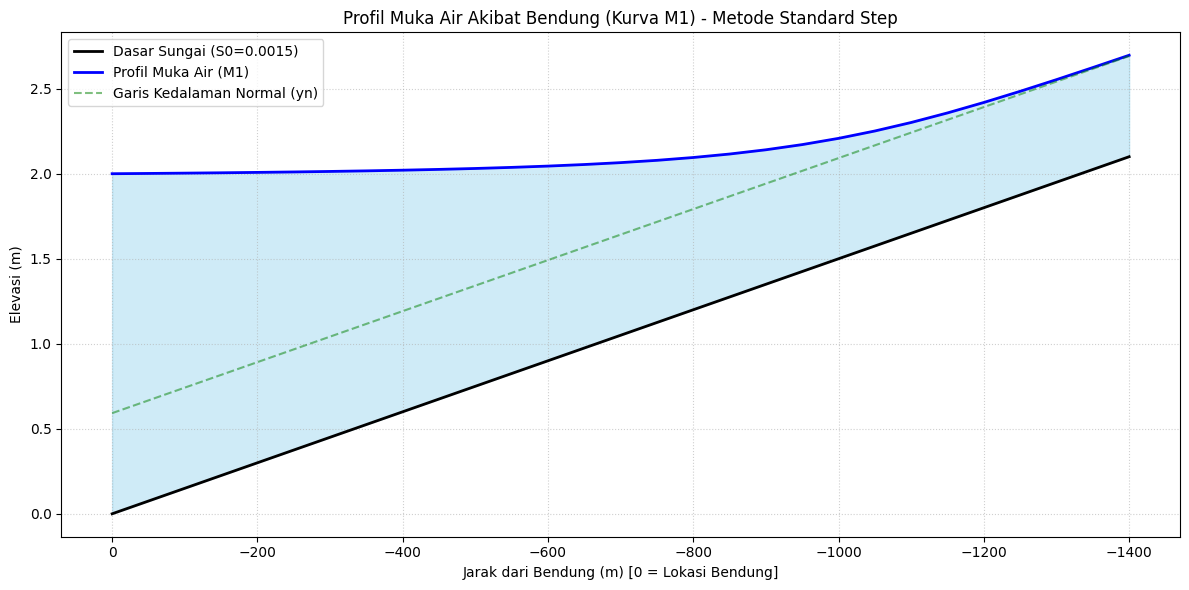


TABEL PROFIL MUKA AIR:
Jarak (m)  | Elev. Dasar  | Kedalaman (y)   | Elev. Air   
-------------------------------------------------------
0          | 0.000        | 2.000           | 2.000       
-50        | 0.075        | 1.927           | 2.002       
-100       | 0.150        | 1.853           | 2.003       
-150       | 0.225        | 1.780           | 2.005       
-200       | 0.300        | 1.708           | 2.008       
-250       | 0.375        | 1.635           | 2.010       
-300       | 0.450        | 1.563           | 2.013       
-350       | 0.525        | 1.492           | 2.017       
-400       | 0.600        | 1.421           | 2.021       
-450       | 0.675        | 1.350           | 2.025       
-500       | 0.750        | 1.281           | 2.031       
-550       | 0.825        | 1.212           | 2.037       
-600       | 0.900        | 1.145           | 2.045       
-650       | 0.975        | 1.079           | 2.054       
-700       | 1.050        | 1.015  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameter Input ---
Q = 5.0          # Debit (m3/s)
B = 10.0         # Lebar saluran (m)
n = 0.03         # Koefisien Manning
S0 = 0.0015      # Kemiringan dasar
g = 9.81         # Gravitasi (m/s2)
y_hulu_bendung = 2.0  # Kedalaman air tepat di hulu bendung (m)
dx = 50          # Interval jarak (m)
tolerance = 0.0001

# --- 2. Perhitungan Parameter Hidraulis ---
q = Q / B
yc = (q**2 / g)**(1/3)

# Mencari Kedalaman Normal (yn) dengan iterasi Manning
yn = 0.5 # Tebakan awal
for _ in range(1000):
    A_n = B * yn
    P_n = B + 2 * yn
    R_n = A_n / P_n
    yn_new = (Q * n / (A_n * R_n**(2/3) * S0**0.5)) * yn # Simple iteration
    if abs(yn_new - yn) < tolerance:
        break
    yn = (yn + yn_new) / 2 # Damping agar stabil

print(f"Kedalaman Kritis (yc): {yc:.3f} m")
print(f"Kedalaman Normal (yn): {yn:.3f} m")

# --- 3. Hitungan Standard Step ---
x_coords = [0]
y_coords = [y_hulu_bendung]
z_coords = [0] # Elevasi dasar di bendung dianggap 0

i = 0
# Hitung ke arah hulu (x negatif) sampai y mendekati yn
while y_coords[i] > (yn + 0.005) and i < 40: # Limit 40 step (2000m)
    y1 = y_coords[i]
    z1 = z_coords[i]

    # Elemen penampang 1
    A1 = B * y1
    v1 = Q / A1
    E1 = z1 + y1 + (v1**2 / (2 * g))
    Sf1 = (n * Q / (A1 * (A1 / (B + 2 * y1))**(2/3)))**2

    # Prediksi elevasi dasar berikutnya (naik ke hulu)
    z2 = z1 + S0 * dx

    # Iterasi untuk mencari y2 di titik x+dx
    y2 = y1 # Tebakan awal y2
    for _ in range(100):
        A2 = B * y2
        v2 = Q / A2
        E2 = z2 + y2 + (v2**2 / (2 * g))
        Sf2 = (n * Q / (A2 * (A2 / (B + 2 * y2))**(2/3)))**2
        Sf_avg = (Sf1 + Sf2) / 2

        # Persamaan Energi: E2 = E1 + Sf_avg * dx
        E2_target = E1 + Sf_avg * dx
        error = E2 - E2_target

        if abs(error) < tolerance:
            break
        y2 -= error * 0.8 # Penyesuaian kedalaman

    x_coords.append(x_coords[i] - dx) # x berkurang ke hulu
    y_coords.append(y2)
    z_coords.append(z2)
    i += 1

# --- 4. Plotting ---
plt.figure(figsize=(12, 6))
dist = np.array(x_coords)
z = np.array(z_coords)
water_level = z + np.array(y_coords)

# Dasar Sungai
plt.plot(dist, z, color='black', linewidth=2, label='Dasar Sungai (S0=0.0015)')
# Muka Air
plt.plot(dist, water_level, color='blue', linewidth=2, label='Profil Muka Air (M1)')
# Garis Normal & Kritis (Hanya untuk referensi elevasi)
plt.plot(dist, z + yn, '--', color='green', alpha=0.5, label='Garis Kedalaman Normal (yn)')

# Arsir area air
plt.fill_between(dist, z, water_level, color='skyblue', alpha=0.4)

plt.title('Profil Muka Air Akibat Bendung (Kurva M1) - Metode Standard Step')
plt.xlabel('Jarak dari Bendung (m) [0 = Lokasi Bendung]')
plt.ylabel('Elevasi (m)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().invert_xaxis() # Balik sumbu X agar hulu di kiri (opsional)
plt.tight_layout()
plt.show()

# Tampilkan Tabel
print("\nTABEL PROFIL MUKA AIR:")
print(f"{'Jarak (m)':<10} | {'Elev. Dasar':<12} | {'Kedalaman (y)':<15} | {'Elev. Air':<12}")
print("-" * 55)
for k in range(len(x_coords)):
    print(f"{x_coords[k]:<10} | {z_coords[k]:<12.3f} | {y_coords[k]:<15.3f} | {z_coords[k]+y_coords[k]:<12.3f}")